# Credit Risk Modelling — Loan Classification
This notebook contains an end-to-end pipeline:
- EDA (quick)
- Preprocessing
- Train & evaluate Logistic Regression, RandomForest, XGBoost
- Optional randomized hyperparameter tuning for XGBoost
- Save best pipeline (preprocessor + model)
- Feature importance / SHAP explanation
- Exports a separate `streamlit_app.py` (lightweight) under `credit_model/`

**How to use**
1. Put `loan_detection.csv` in the same folder as this notebook.
2. Run cells in order.
3. Install missing packages with pip (e.g. `pip install xgboost shap streamlit lightgbm imbalanced-learn`).


In [20]:
# Imports & config
import os, warnings, pickle, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

RANDOM_STATE = 42
DATA_PATH = "loan_detection.csv"   # put your CSV here
OUTPUT_DIR = "credit_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready. DATA_PATH =", DATA_PATH)


Config ready. DATA_PATH = loan_detection.csv


In [21]:
# Load data
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

# Basic info
print("\nColumn count:", len(df.columns))
print("\nMissing values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

# Identify target
candidates = [c for c in df.columns if 'loan' in c.lower() or 'loan_status' in c.lower()]
print("\nCandidate target columns:", candidates)
TARGET = 'Loan_Status_label' if 'Loan_Status_label' in df.columns else (candidates[0] if candidates else None)
print("Using TARGET =", TARGET)
if TARGET is None:
    raise ValueError("No target detected. Set TARGET variable to target column name and re-run.")


Shape: (41188, 60)


,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0



Column count: 60

Missing values (top 20):
age                    0
campaign               0
pdays                  0
previous               0
no_previous_contact    0
not_working            0
job_admin.             0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_divorced       0
marital_married        0
dtype: int64

Candidate target columns: ['loan_no', 'loan_unknown', 'loan_yes', 'Loan_Status_label']
Using TARGET = Loan_Status_label


In [22]:
from sklearn.model_selection import train_test_split

y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))


Train shape: (32950, 59) Test shape: (8238, 59)
Train target distribution:
 Loan_Status_label
0    0.887344
1    0.112656
Name: proportion, dtype: float64


In [23]:
# Preprocessing: median impute + standard scaling for numeric columns.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns detected:", len(num_cols))

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols)
], remainder="drop")   # remainder drop because dataset already looks encoded


Numeric columns detected: 59


In [24]:
# Baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

log_pipe = Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
rf_pipe  = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))])
xgb_pipe = Pipeline([("pre", preprocessor), ("clf", XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))])

models = {"LogisticRegression": log_pipe, "RandomForest": rf_pipe, "XGBoost": xgb_pipe}
results = {}

for name, pipe in models.items():
    print(f"\nTraining {name} ...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)
    print(f"{name} -> Accuracy: {acc:.4f}, ROC_AUC: {roc:.4f}")
    results[name] = {"pipeline": pipe, "accuracy": acc, "roc_auc": roc, "report": classification_report(y_test, preds, output_dict=True)}

# Summary
import pandas as pd
summary = pd.DataFrame([{ "model": k, "accuracy": v["accuracy"], "roc_auc": v["roc_auc"] } for k,v in results.items()])
display(summary.sort_values("roc_auc", ascending=False))



Training LogisticRegression ...
LogisticRegression -> Accuracy: 0.8984, ROC_AUC: 0.7648

Training RandomForest ...
RandomForest -> Accuracy: 0.8999, ROC_AUC: 0.7808

Training XGBoost ...
XGBoost -> Accuracy: 0.9006, ROC_AUC: 0.7788


,model,accuracy,roc_auc
1,RandomForest,0.899854,0.780791
2,XGBoost,0.900583,0.778759
0,LogisticRegression,0.898398,0.764776


In [25]:
# Select best by ROC AUC and save
best_name = max(results.keys(), key=lambda k: results[k]["roc_auc"])
best_pipeline = results[best_name]["pipeline"]
print("Best:", best_name, results[best_name]["roc_auc"])

# Save pipeline
with open(os.path.join(OUTPUT_DIR, "best_model_pipeline.pkl"), "wb") as f:
    pickle.dump(best_pipeline, f)
print("Saved pipeline to", os.path.join(OUTPUT_DIR, "best_model_pipeline.pkl"))

# Save classification report CSV
pd.DataFrame(results[best_name]["report"]).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))
print("Saved classification report")


Best: RandomForest 0.7807913256521534
Saved pipeline to credit_model\best_model_pipeline.pkl
Saved classification report


In [26]:
# Feature importance or coefficients
best_clf = best_pipeline.named_steps["clf"]

if hasattr(best_clf, "feature_importances_"):
    # For tree-based models
    importances = best_clf.feature_importances_
    feat_names = num_cols   # preprocessor only used numeric columns; keep this mapping
    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)
    imp_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importances.csv"), index=False)
    display(imp_df.head(20))
else:
    # For logistic regression
    coefs = best_clf.coef_[0]
    coef_df = pd.DataFrame({"feature": num_cols, "coef": coefs})
    coef_df["abs"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs", ascending=False).drop(columns="abs")
    coef_df.to_csv(os.path.join(OUTPUT_DIR, "logreg_coefficients.csv"), index=False)
    display(coef_df.head(20))


,feature,importance
2,pdays,0.122201
58,poutcome_success,0.101786
0,age,0.096750
4,no_previous_contact,0.093657
3,previous,0.043572
46,month_mar,0.038772
49,month_oct,0.033630
1,campaign,0.030983
40,contact_telephone,0.021940
39,contact_cellular,0.021823


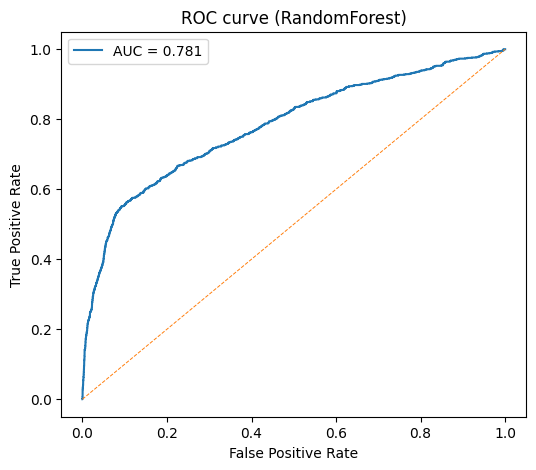

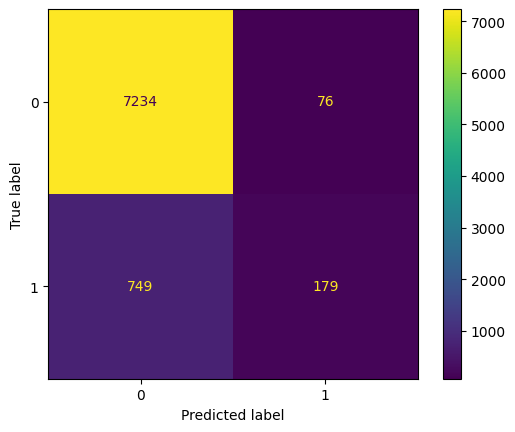

Saved ROC curve to credit_model\roc_curve.png


<Figure size 640x480 with 0 Axes>

In [27]:
# Plot ROC & confusion matrix for best pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

y_proba = best_pipeline.predict_proba(X_test)[:,1]
y_pred  = best_pipeline.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], "--", linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve ({best_name})")
plt.legend()
plt.show()

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test, y_test)
plt.show()

# Save ROC plot
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150)
print("Saved ROC curve to", os.path.join(OUTPUT_DIR, "roc_curve.png"))


ROC curve saved to: credit_model/roc_curve.png


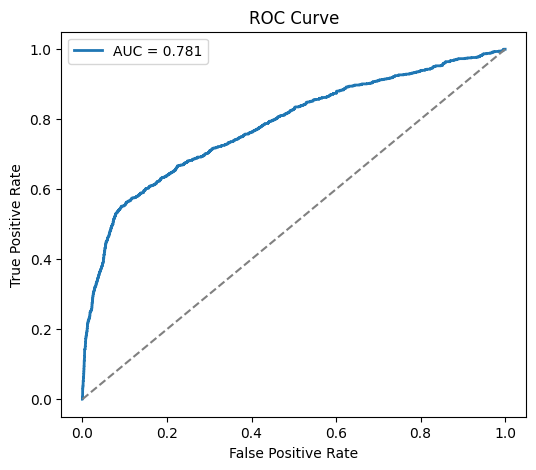

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# compute roc points
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ALWAYS create a NEW figure before plotting
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# SAVE BEFORE SHOW (important!)
save_path = "credit_model/roc_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

print(f"ROC curve saved to: {save_path}")

# Now show in notebook (optional)
plt.show()

In [29]:
import pickle, os
os.makedirs("credit_model", exist_ok=True)

with open("credit_model/best_model_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Saved best model pipeline to credit_model/best_model_pipeline.pkl")


Saved best model pipeline to credit_model/best_model_pipeline.pkl
